# Posture analysis appendix notebook

This notebook is designed as a readable appendix for a manuscript.

- It reproduces the core logic from `paired_test/paired_hypotheses_pipeline.py`.
- It does **not** save result tables or plots to disk.
- It computes and displays statistical outputs and figures directly in notebook cells.

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

project_root = Path.cwd()
paired_dir = project_root / "paired_test"
input_csv = paired_dir / "Final_data_frame_filtered_enrollment_pdg_merged_fes_merged_P-N_duration.csv"

print(f"Project root: {project_root}")
print(f"Input CSV exists: {input_csv.exists()} -> {input_csv}")


def require_cols(df: pd.DataFrame, cols: list[str], label: str) -> None:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required {label} columns: {missing}")


def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> None:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")


def sanitize_columns_for_patsy(df: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, str]]:
    old_cols = df.columns.tolist()
    new_cols = []
    for c in old_cols:
        c2 = c.strip().replace(" ", "_").replace("-", "_").replace("/", "_")
        new_cols.append(c2)
    mapping = {o: n for o, n in zip(old_cols, new_cols) if o != n}
    if mapping:
        df = df.rename(columns=mapping).copy()
    return df, mapping


def describe_series(x: pd.Series) -> dict:
    x = x.dropna()
    if x.shape[0] == 0:
        return {"n": 0, "mean": np.nan, "sd": np.nan, "median": np.nan, "iqr": np.nan, "min": np.nan, "max": np.nan}
    q1 = float(np.nanpercentile(x, 25))
    q3 = float(np.nanpercentile(x, 75))
    return {
        "n": int(x.shape[0]),
        "mean": float(np.nanmean(x)),
        "sd": float(np.nanstd(x, ddof=1)) if x.shape[0] > 1 else np.nan,
        "median": float(np.nanmedian(x)),
        "iqr": float(q3 - q1),
        "min": float(np.nanmin(x)),
        "max": float(np.nanmax(x)),
    }


def bh_fdr(pvals: pd.Series, alpha: float = 0.05) -> pd.DataFrame:
    p = pvals.copy()
    mask = p.notna()
    q = pd.Series(np.nan, index=p.index, dtype=float)
    reject = pd.Series(False, index=p.index, dtype=bool)
    if mask.sum() > 0:
        rej, qvals, _, _ = multipletests(p[mask].values, alpha=alpha, method="fdr_bh")
        q.loc[mask] = qvals
        reject.loc[mask] = rej
    return pd.DataFrame({"p": p, "q": q, "reject_fdr": reject})


def cohen_dz_paired(delta: pd.Series) -> float:
    d = delta.dropna().values
    if d.shape[0] < 2:
        return np.nan
    sd = float(np.std(d, ddof=1))
    if sd == 0:
        return np.nan
    return float(np.mean(d) / sd)


def rank_biserial_from_wilcoxon(delta: pd.Series) -> float:
    d = delta.dropna().values
    if d.shape[0] < 2:
        return np.nan
    d = d[d != 0]
    if d.shape[0] < 2:
        return np.nan
    ranks = stats.rankdata(np.abs(d))
    w_pos = float(np.sum(ranks[d > 0]))
    w_neg = float(np.sum(ranks[d < 0]))
    denom = w_pos + w_neg
    if denom == 0:
        return np.nan
    return float((w_pos - w_neg) / denom)


def fit_ols(formula: str, data: pd.DataFrame, cov_type: str = "HC3"):
    return smf.ols(formula, data=data, missing="drop").fit(cov_type=cov_type)


def extract_term(res, term: str) -> dict:
    if term not in res.params.index:
        return {"term": term, "beta": np.nan, "se": np.nan, "p": np.nan, "ci_low": np.nan, "ci_high": np.nan}
    ci = res.conf_int().loc[term].tolist()
    return {
        "term": term,
        "beta": float(res.params[term]),
        "se": float(res.bse[term]),
        "p": float(res.pvalues[term]),
        "ci_low": float(ci[0]),
        "ci_high": float(ci[1]),
    }


def omnibus_wald_for_prefix(res, term_prefix: str) -> dict:
    terms = [t for t in res.params.index if t.startswith(term_prefix + "[T.")]
    if len(terms) == 0:
        return {"factor": term_prefix, "n_terms": 0, "stat": np.nan, "df_num": np.nan, "df_denom": np.nan, "p": np.nan, "test": "NA"}

    names = list(res.params.index)
    r = np.zeros((len(terms), len(names)), dtype=float)
    for i, t in enumerate(terms):
        r[i, names.index(t)] = 1.0

    w = res.wald_test(r)
    return {
        "factor": term_prefix,
        "n_terms": int(len(terms)),
        "stat": float(np.asarray(w.statistic).squeeze()),
        "df_num": float(getattr(w, "df_num", len(terms))),
        "df_denom": float(getattr(w, "df_denom", np.nan)),
        "p": float(w.pvalue),
        "test": "Wald",
    }


def show_df(title: str, frame: pd.DataFrame, n: int = 20) -> None:
    display(Markdown(f"### {title}"))
    display(frame.head(n).round(4))

Project root: d:\mprgs\!VSC\articles--2026Posture
Input CSV exists: True -> d:\mprgs\!VSC\articles--2026Posture\paired_test\Final_data_frame_filtered_enrollment_pdg_merged_fes_merged_P-N_duration.csv


In [11]:
df_raw = pd.read_csv(input_csv)
df, col_map = sanitize_columns_for_patsy(df_raw)

id_col = "study_id"
group_col = "group"
sex_col = "pohlavi"
age_col = "age_0"
duration_col = "duration_pd"
ledd_col = "levodopa_equivalent"

cog_cols = ["moca", "tmt_a", "tmt_b", "tmt_a_chyby", "tmt_b_chyby", "jolo"]
gait_cols = ["w_ex_time_meanN1N2", "w_ex_time_meanP1P2", "time_meanP_meanN"]

required_primary = [
    "pre_rest_tcc", "pre_cog_tcc",
    "pre_stand_ucc", "post_stand_ucc",
    "pre_rest_pisa", "post_rest_pisa",
]

require_cols(df, [id_col, group_col, sex_col, age_col], "core")
require_cols(df, required_primary, "primary posture delta")

if df[id_col].duplicated().any():
    raise ValueError(f"Duplicate IDs found in {id_col}")

coerce_numeric(df, [age_col, duration_col, ledd_col] + cog_cols + gait_cols + required_primary)

df["sex_bin"] = df[sex_col].astype(str).str.strip().str.upper().map({"F": 0, "M": 1})
df["sex_bin"] = pd.to_numeric(df["sex_bin"], errors="coerce")
df[group_col] = df[group_col].astype("category")

df["delta_tcc_cog"] = df["pre_cog_tcc"] - df["pre_rest_tcc"]
df["delta_ucc_walk_stand"] = df["post_stand_ucc"] - df["pre_stand_ucc"]
df["delta_pisa_walk_rest"] = df["post_rest_pisa"] - df["pre_rest_pisa"]

if {"post_rest_ucc", "pre_rest_ucc"}.issubset(df.columns):
    df["delta_ucc_walk_rest"] = pd.to_numeric(df["post_rest_ucc"], errors="coerce") - pd.to_numeric(df["pre_rest_ucc"], errors="coerce")
if {"post_rest_tcc", "pre_rest_tcc"}.issubset(df.columns):
    df["delta_tcc_walk_rest"] = pd.to_numeric(df["post_rest_tcc"], errors="coerce") - pd.to_numeric(df["pre_rest_tcc"], errors="coerce")
if {"post_rest_back", "pre_rest_back"}.issubset(df.columns):
    df["delta_back_walk_rest"] = pd.to_numeric(df["post_rest_back"], errors="coerce") - pd.to_numeric(df["pre_rest_back"], errors="coerce")

meta = pd.DataFrame([
    {
        "n_subjects": int(df.shape[0]),
        "n_columns": int(df.shape[1]),
        "group_counts": df[group_col].value_counts(dropna=False).to_dict(),
        "sex_counts_raw": df[sex_col].value_counts(dropna=False).to_dict(),
        "renamed_columns": len(col_map),
    }
])
show_df("Dataset overview", meta)

preview_cols = [id_col, group_col, sex_col, age_col, "delta_tcc_cog", "delta_ucc_walk_stand", "delta_pisa_walk_rest"]
show_df("Data preview", df[preview_cols])

### Dataset overview

,n_subjects,n_columns,group_counts,sex_counts_raw,renamed_columns
0,100,67,"{'TD': 51, 'PIGD': 32, 'PD_UNCLASSIFIED': 17}","{'M': 70, 'F': 30}",1


### Data preview

,study_id,group,pohlavi,age_0,delta_tcc_cog,delta_ucc_walk_stand,delta_pisa_walk_rest
0,BIO-PD02,PD_UNCLASSIFIED,M,70.1,-2.523,-2.240,0.900
1,BIO-PD04,TD,F,67.5,0.227,0.041,0.137
2,BIO-PD05,PIGD,M,80.2,0.469,1.194,-0.480
3,BIO-PD06,PD_UNCLASSIFIED,M,66.3,2.340,2.638,-0.307
4,BIO-PD07,TD,M,43.2,0.442,1.006,1.540
5,BIO-PD10,PIGD,F,46.4,0.734,8.640,-0.153
6,BIO-PD100,PIGD,F,51.0,-1.680,10.960,0.056
7,BIO-PD102,TD,M,66.3,-1.687,0.783,0.648
8,BIO-PD103,TD,F,66.8,-1.986,1.650,0.079
9,BIO-PD104,PD_UNCLASSIFIED,M,74.3,-3.098,3.338,0.184


## Primary outcomes

This section reports the three primary delta endpoints with normality-aware testing and FDR correction.
Plots show both the overall distribution and between-group patterns.

### Primary delta tests (FDR corrected)

,endpoint,test,n,mean,sd,median,iqr,statistic,p,normality_shapiro_p,rank_biserial,p,q,reject_fdr
0,delta_tcc_cog,wilcoxon_signed_rank,99,-0.6372,2.8180,-0.638,3.0910,1672.0,0.0051,0.0005,-0.3244,0.0051,0.007,True
1,delta_ucc_walk_stand,wilcoxon_signed_rank,98,1.0329,4.5226,1.404,4.6807,1639.0,0.0053,0.0003,0.3243,0.0053,0.007,True
2,delta_pisa_walk_rest,wilcoxon_signed_rank,100,0.1378,0.5236,0.098,0.5315,1741.0,0.0070,0.0236,0.3105,0.0070,0.007,True


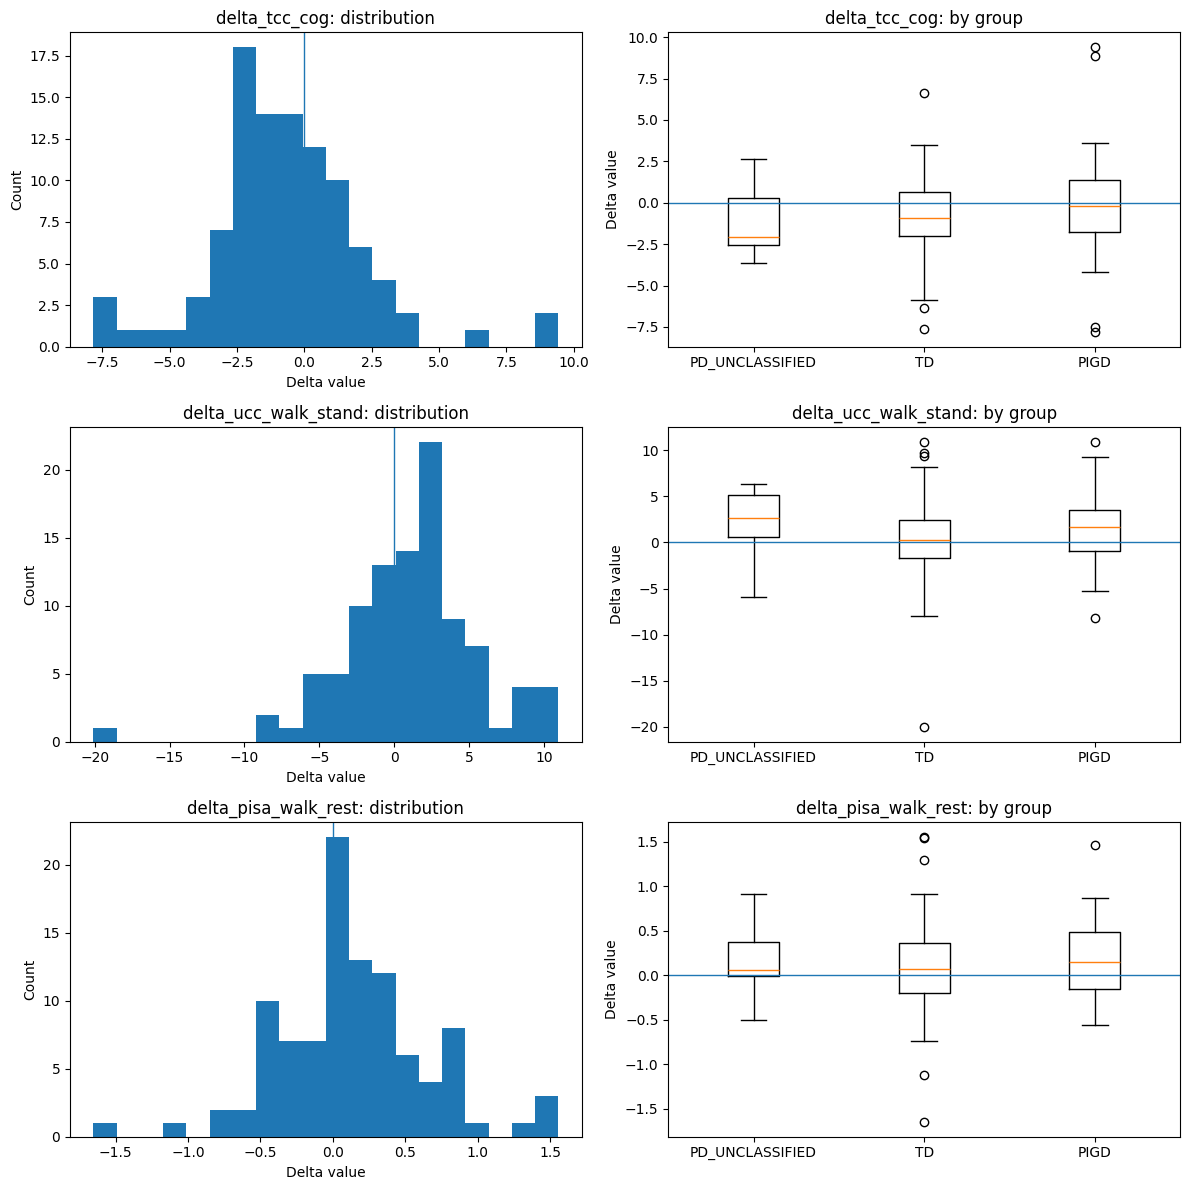

In [ ]:
primary_endpoints = ["delta_tcc_cog", "delta_ucc_walk_stand", "delta_pisa_walk_rest"]
primary_rows = []

for dcol in primary_endpoints:
    delta = df[dcol]
    desc = describe_series(delta)
    d_nonan = delta.dropna().values

    shapiro_p = np.nan
    if 3 <= d_nonan.shape[0] <= 5000:
        try:
            shapiro_p = float(stats.shapiro(d_nonan).pvalue)
        except Exception:
            shapiro_p = np.nan

    use_wilcoxon = (not np.isnan(shapiro_p)) and (shapiro_p < 0.05)

    if use_wilcoxon:
        w = stats.wilcoxon(d_nonan, zero_method="wilcox", alternative="two-sided", mode="auto")
        test_name = "wilcoxon_signed_rank"
        stat = float(w.statistic)
        p = float(w.pvalue)
        effect_name = "rank_biserial"
        effect_val = rank_biserial_from_wilcoxon(delta)
    else:
        t = stats.ttest_1samp(d_nonan, popmean=0.0)
        test_name = "one_sample_t_on_delta"
        stat = float(t.statistic)
        p = float(t.pvalue)
        effect_name = "cohen_dz"
        effect_val = cohen_dz_paired(delta)

    row = {
        "endpoint": dcol,
        "test": test_name,
        "n": desc["n"],
        "mean": desc["mean"],
        "sd": desc["sd"],
        "median": desc["median"],
        "iqr": desc["iqr"],
        "statistic": stat,
        "p": p,
        "normality_shapiro_p": shapiro_p,
        effect_name: effect_val,
    }
    primary_rows.append(row)

primary_df = pd.DataFrame(primary_rows)
primary_fdr = bh_fdr(primary_df["p"], alpha=0.05)
primary_df["q"] = primary_fdr["q"]
primary_df["reject_fdr"] = primary_fdr["reject_fdr"]
show_df("Primary delta tests (FDR corrected)", primary_df)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for i, endpoint in enumerate(primary_endpoints):
    vals = df[endpoint].dropna()

    ax_hist = axes[i, 0]
    ax_hist.hist(vals, bins=20)
    ax_hist.axvline(0, linewidth=1)
    ax_hist.set_title(f"{endpoint}: distribution")
    ax_hist.set_xlabel("Delta value")
    ax_hist.set_ylabel("Count")

    ax_box = axes[i, 1]
    sub = df[[endpoint, group_col]].dropna()
    groups = list(pd.unique(sub[group_col]))
    data = [sub.loc[sub[group_col] == g, endpoint].values for g in groups]
    ax_box.boxplot(data, tick_labels=groups, showfliers=True)
    ax_box.axhline(0, linewidth=1)
    ax_box.set_title(f"{endpoint}: by group")
    ax_box.set_ylabel("Delta value")

plt.tight_layout()
plt.show()

## Multivariable and exploratory analyses

This section summarizes H1, H2, H3, H4, H6, and an H8-inspired exploratory clustering analysis.
All outputs are displayed inline without writing result files.

In [ ]:
h1_specs = [
    ("delta_tcc_cog", "pre_rest_tcc"),
    ("delta_ucc_walk_stand", "pre_stand_ucc"),
    ("delta_pisa_walk_rest", "pre_rest_pisa"),
]

h1_models, h1_terms, h1_baseline_p = [], [], []
for outcome, baseline in h1_specs:
    formula = f"{outcome} ~ {baseline} + {age_col} + sex_bin"
    res = fit_ols(formula, df)
    model_label = f"H1:{outcome}_on_{baseline}"
    h1_models.append({"model": model_label, "formula": formula, "n": int(res.nobs), "r2": float(res.rsquared)})

    b = extract_term(res, baseline)
    b.update({"model": model_label})
    h1_terms.append(b)
    h1_baseline_p.append(b["p"])

    for cov in [age_col, "sex_bin"]:
        tr = extract_term(res, cov)
        tr.update({"model": model_label})
        h1_terms.append(tr)

h1_models_df = pd.DataFrame(h1_models)
h1_terms_df = pd.DataFrame(h1_terms)
fdr_h1 = bh_fdr(pd.Series(h1_baseline_p), alpha=0.05).reset_index(drop=True)
mask_h1 = h1_terms_df["term"].isin([b for _, b in h1_specs])
if int(mask_h1.sum()) == len(h1_specs):
    h1_terms_df.loc[mask_h1, "q"] = fdr_h1["q"].values
    h1_terms_df.loc[mask_h1, "reject_fdr"] = fdr_h1["reject_fdr"].values

show_df("H1 models", h1_models_df)
show_df("H1 terms", h1_terms_df)

h2_specs = [
    ("delta_ucc_walk_stand", "w_ex_time_meanP1P2"),
    ("delta_ucc_walk_stand", "time_meanP_meanN"),
    ("delta_pisa_walk_rest", "w_ex_time_meanP1P2"),
]

h2_rows, h2_pvals = [], []
for outcome, gait in h2_specs:
    if gait not in df.columns:
        continue

    mask = df[gait].notna() & df[outcome].notna()
    if int(mask.sum()) >= 5:
        rho, p_s = stats.spearmanr(df.loc[mask, gait].values, df.loc[mask, outcome].values)
        h2_rows.append({"test": "spearman", "outcome": outcome, "predictor": gait, "n": int(mask.sum()), "rho": float(rho), "p": float(p_s)})
        h2_pvals.append(float(p_s))

    formula = f"{outcome} ~ {gait} + {age_col} + sex_bin"
    res = fit_ols(formula, df)
    t = extract_term(res, gait)
    h2_rows.append({"test": "ols_HC3", "outcome": outcome, "predictor": gait, "n": int(res.nobs), "beta": t["beta"], "se": t["se"], "p": t["p"], "ci_low": t["ci_low"], "ci_high": t["ci_high"]})
    h2_pvals.append(t["p"])

h2_df = pd.DataFrame(h2_rows)
h2_fdr = bh_fdr(pd.Series(h2_pvals), alpha=0.05).reset_index(drop=True)
h2_df["q"] = h2_fdr["q"].values
h2_df["reject_fdr"] = h2_fdr["reject_fdr"].values
show_df("H2 gait links", h2_df)

h3_rows = []
for pred in ["moca", "tmt_a", "tmt_b", "tmt_a_chyby", "tmt_b_chyby", "jolo"]:
    if pred not in df.columns:
        continue
    formula = f"delta_tcc_cog ~ {pred} + {age_col} + sex_bin"
    res = fit_ols(formula, df)
    tr = extract_term(res, pred)
    h3_rows.append({"predictor": pred, "n": int(res.nobs), "formula": formula, **tr})

h3_df = pd.DataFrame(h3_rows)
if not h3_df.empty:
    fdr_h3 = bh_fdr(h3_df["p"], alpha=0.05)
    h3_df = pd.concat([h3_df.reset_index(drop=True), fdr_h3.reset_index(drop=True)[["q", "reject_fdr"]]], axis=1)
show_df("H3 cognition links", h3_df)

h4_rows = []
for outcome in ["delta_tcc_cog", "delta_ucc_walk_stand", "delta_pisa_walk_rest"]:
    formula = f"{outcome} ~ C({group_col}) + {age_col} + sex_bin"
    res = fit_ols(formula, df)
    omni = omnibus_wald_for_prefix(res, f"C({group_col})")
    h4_rows.append({"outcome": outcome, "n": int(res.nobs), "formula": formula, **omni})

h4_df = pd.DataFrame(h4_rows)
h4_fdr = bh_fdr(h4_df["p"], alpha=0.05)
h4_df = pd.concat([h4_df.reset_index(drop=True), h4_fdr.reset_index(drop=True)[["q", "reject_fdr"]]], axis=1)
show_df("H4 group omnibus tests", h4_df)

h6_rows = []
if ledd_col in df.columns:
    for outcome in ["delta_ucc_walk_stand", "delta_pisa_walk_rest"]:
        covs = [ledd_col]
        if duration_col in df.columns:
            covs.append(duration_col)
        covs.extend([age_col, "sex_bin"])
        formula = f"{outcome} ~ " + " + ".join(covs)
        res = fit_ols(formula, df)
        tr = extract_term(res, ledd_col)
        h6_rows.append({"outcome": outcome, "n": int(res.nobs), "formula": formula, **tr})

h6_df = pd.DataFrame(h6_rows)
if not h6_df.empty:
    fdr_h6 = bh_fdr(h6_df["p"], alpha=0.05)
    h6_df = pd.concat([h6_df.reset_index(drop=True), fdr_h6.reset_index(drop=True)[["q", "reject_fdr"]]], axis=1)
show_df("H6 LEDD associations", h6_df)

display(Markdown("### Exploratory clustering on delta vectors (H8-inspired)"))
delta_features = [c for c in [
    "delta_tcc_cog",
    "delta_ucc_walk_stand",
    "delta_pisa_walk_rest",
    "delta_ucc_walk_rest",
    "delta_tcc_walk_rest",
    "delta_back_walk_rest",
] if c in df.columns]

if len(delta_features) >= 3:
    x = df[delta_features].copy()
    mask = x.notna().all(axis=1)
    xc = x.loc[mask].values

    if xc.shape[0] >= 10:
        scaler = StandardScaler()
        xz = scaler.fit_transform(xc)

        best_k, best_sil, best_model = None, -np.inf, None
        for k in [2, 3, 4, 5]:
            if xz.shape[0] < (k + 5):
                continue
            km = KMeans(n_clusters=k, n_init=50, random_state=42)
            labels = km.fit_predict(xz)
            sil = float(silhouette_score(xz, labels))
            if sil > best_sil:
                best_k, best_sil, best_model = k, sil, km

        if best_model is not None:
            labels = best_model.predict(xz)
            cluster_df = df.loc[mask, [id_col, group_col]].copy()
            cluster_df["cluster"] = labels

            cluster_meta = pd.DataFrame([{
                "status": "ok",
                "n_clustered": int(mask.sum()),
                "best_k": int(best_k),
                "silhouette": float(best_sil),
                "features": delta_features,
            }])
            show_df("H8 clustering meta", cluster_meta)

            cluster_sizes = cluster_df["cluster"].value_counts().sort_index().rename("n").reset_index()
            show_df("H8 cluster sizes", cluster_sizes)

            pca = PCA(n_components=2, random_state=42)
            x2 = pca.fit_transform(xz)

            fig, ax = plt.subplots(figsize=(8, 6))
            sc = ax.scatter(x2[:, 0], x2[:, 1], c=labels, s=40)
            ax.set_title("H8 exploratory clusters (PCA projection)")
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")
            plt.colorbar(sc, ax=ax, label="Cluster")
            plt.tight_layout()
            plt.show()
        else:
            display(Markdown("No suitable clustering solution found for H8."))
    else:
        display(Markdown("Not enough complete rows for H8 clustering."))
else:
    display(Markdown("Not enough delta features for H8 clustering."))


===== PRIMARY_delta_tests_with_FDR.csv | shape=(3, 14) =====


,endpoint,test,n,mean,sd,median,iqr,statistic,p,normality_shapiro_p,rank_biserial,p.1,q,reject_fdr
0,delta_tcc_cog,wilcoxon_signed_rank,99,-0.637202,2.817986,-0.638,3.09100,1672.0,0.005068,0.000472,-0.324444,0.005068,0.007025,True
1,delta_ucc_walk_stand,wilcoxon_signed_rank,98,1.032929,4.522622,1.404,4.68075,1639.0,0.005319,0.000283,0.324263,0.005319,0.007025,True
2,delta_pisa_walk_rest,wilcoxon_signed_rank,100,0.137780,0.523626,0.098,0.53150,1741.0,0.007025,0.023580,0.310495,0.007025,0.007025,True



===== H1_terms.csv | shape=(9, 9) =====


,term,beta,se,p,ci_low,ci_high,model,q,reject_fdr
0,pre_rest_tcc,-0.012387,0.063993,0.846513,-0.137810,0.113036,H1:delta_tcc_cog_on_pre_rest_tcc,0.846513,False
1,age_0,0.003075,0.026545,0.907778,-0.048952,0.055102,H1:delta_tcc_cog_on_pre_rest_tcc,NaN,NaN
2,sex_bin,-0.210194,0.620957,0.734987,-1.427248,1.006860,H1:delta_tcc_cog_on_pre_rest_tcc,NaN,NaN
3,pre_stand_ucc,-0.302925,0.078660,0.000118,-0.457097,-0.148754,H1:delta_ucc_walk_stand_on_pre_stand_ucc,0.000353,True
4,age_0,0.047434,0.039073,0.224760,-0.029148,0.124015,H1:delta_ucc_walk_stand_on_pre_stand_ucc,NaN,NaN
5,sex_bin,0.566667,1.429872,0.691879,-2.235832,3.369165,H1:delta_ucc_walk_stand_on_pre_stand_ucc,NaN,NaN
6,pre_rest_pisa,-0.066261,0.071399,0.353389,-0.206201,0.073679,H1:delta_pisa_walk_rest_on_pre_rest_pisa,0.530083,False
7,age_0,0.004111,0.005281,0.436239,-0.006239,0.014462,H1:delta_pisa_walk_rest_on_pre_rest_pisa,NaN,NaN
8,sex_bin,0.044925,0.091763,0.624432,-0.134927,0.224778,H1:delta_pisa_walk_rest_on_pre_rest_pisa,NaN,NaN



===== H2_gait_links.csv | shape=(6, 13) =====


...

,outcome,n,formula,factor,n_terms,stat,df_num,df_denom,p,test,q,reject_fdr
0,delta_tcc_cog,99,delta_tcc_cog ~ C(group) + age_0 + sex_bin,C(group),2,1.691533,2.0,2.0,0.429228,Wald,0.643842,False
1,delta_ucc_walk_stand,98,delta_ucc_walk_stand ~ C(group) + age_0 + sex_bin,C(group),2,5.163549,2.0,2.0,0.075640,Wald,0.226919,False
2,delta_pisa_walk_rest,100,delta_pisa_walk_rest ~ C(group) + age_0 + sex_bin,C(group),2,0.538595,2.0,2.0,0.763916,Wald,0.763916,False



===== H6_LEDD_associations.csv | shape=(2, 11) =====


,outcome,n,formula,term,beta,se,p,ci_low,ci_high,q,reject_fdr
0,delta_ucc_walk_stand,89,delta_ucc_walk_stand ~ levodopa_equivalent + d...,levodopa_equivalent,-0.001470,0.000916,0.108387,-0.003265,0.000325,0.157984,False
1,delta_pisa_walk_rest,91,delta_pisa_walk_rest ~ levodopa_equivalent + d...,levodopa_equivalent,0.000149,0.000105,0.157984,-0.000058,0.000356,0.157984,False



===== H8_cluster_meta.csv | shape=(1, 5) =====


,status,n_clustered,features,best_k,silhouette
0,ok,97,"['delta_tcc_cog', 'delta_ucc_walk_stand', 'del...",3,0.165915
